# Summary Statistics for Founder Prior Experience and Position Sample
This notebook provides basic descriptive statistics for overall founder-level prior experience and details of the position held directly prior to becoming a founder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11

In [2]:
base_dir = "../../D - Data"
matched_path = os.path.join(base_dir, "D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv")
prior_pos_path = os.path.join(base_dir, "D2 - Datasets for Matching/Founder_Prior_Position_Details.csv")

print("Loading refined matched dataset (only necessary columns)...")
cols_to_load = [
    'user_id', 'founding_event_number', 'years_since_first_job', 
    'total_prior_positions', 'max_prior_seniority',
    'exp_sen_1', 'exp_sen_2', 'exp_sen_3', 'exp_sen_4', 'exp_sen_5', 'exp_sen_6', 'exp_sen_7',
    'TOTALRAISED', 'YEARFOUNDED', 'EMPLOYEES', 'REVENUE', 'Bankrupt', 'Acquired_IPO', 'DEALSIZE', 'SeriesA'
]
df_matched = pd.read_csv(matched_path, usecols=cols_to_load, low_memory=False)
print(f"Loaded {len(df_matched):,} rows from matched dataset.")

print("Loading pre-extracted prior position details...")
df_prior = pd.read_csv(prior_pos_path, low_memory=False)
print(f"Loaded {len(df_prior):,} rows from prior positions details.")

Loading refined matched dataset (only necessary columns)...


Loaded 1,239,185 rows from matched dataset.
Loading pre-extracted prior position details...


Loaded 1,239,185 rows from prior positions details.


In [3]:
# Merge prior position details into matched dataset
df = pd.merge(df_matched, df_prior, on=['user_id', 'founding_event_number'], how='left')
print(f"Merged dataset shape: {df.shape}")
print(df.info())

Merged dataset shape: (1239185, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239185 entries, 0 to 1239184
Data columns (total 27 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   user_id                  1239185 non-null  int64  
 1   founding_event_number    1239185 non-null  int64  
 2   years_since_first_job    1239185 non-null  float64
 3   total_prior_positions    1239185 non-null  int64  
 4   max_prior_seniority      1239185 non-null  int64  
 5   exp_sen_1                1046343 non-null  float64
 6   exp_sen_2                1046343 non-null  float64
 7   exp_sen_3                1046343 non-null  float64
 8   exp_sen_4                1046343 non-null  float64
 9   exp_sen_5                1046343 non-null  float64
 10  exp_sen_6                1046343 non-null  float64
 11  exp_sen_7                1046343 non-null  float64
 12  TOTALRAISED              40336 non-null    float64
 13  YEARFO

In [4]:
print("--- Overall Founder Experience Summary Statistics ---")
experience_cols = ['years_since_first_job', 'total_prior_positions', 'max_prior_seniority']
print(df[experience_cols].describe())

print("\n--- Summary Statistics of Years of Experience by Seniority Level ---")
sen_experience_cols = [f'exp_sen_{i}' for i in range(1, 8)]
print(df[sen_experience_cols].describe())

--- Overall Founder Experience Summary Statistics ---


       years_since_first_job  total_prior_positions  max_prior_seniority
count           1.239185e+06           1.239185e+06         1.239185e+06
mean            9.354806e+00           3.946918e+00         3.620203e+00
std             8.482469e+00           3.589418e+00         2.239446e+00
min             0.000000e+00           0.000000e+00         0.000000e+00
25%             2.584531e+00           1.000000e+00         2.000000e+00
50%             7.334702e+00           3.000000e+00         4.000000e+00
75%             1.400137e+01           6.000000e+00         5.000000e+00
max             7.091581e+01           1.580000e+02         7.000000e+00

--- Summary Statistics of Years of Experience by Seniority Level ---


          exp_sen_1     exp_sen_2     exp_sen_3     exp_sen_4     exp_sen_5  \
count  1.046343e+06  1.046343e+06  1.046343e+06  1.046343e+06  1.046343e+06   
mean   2.054680e+00  2.423523e+00  1.338312e+00  1.517810e+00  2.705569e+00   
std    4.163350e+00  4.570525e+00  3.422507e+00  3.684340e+00  5.741097e+00   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%    1.670089e-01  4.161533e-01  0.000000e+00  0.000000e+00  0.000000e+00   
75%    2.584531e+00  3.167693e+00  1.002053e+00  1.418207e+00  3.000684e+00   
max    2.740068e+02  2.444134e+02  2.416181e+02  2.800000e+02  1.930787e+02   

          exp_sen_6     exp_sen_7  
count  1.046343e+06  1.046343e+06  
mean   1.035844e+00  6.234385e-01  
std    3.809074e+00  2.969902e+00  
min    0.000000e+00  0.000000e+00  
25%    0.000000e+00  0.000000e+00  
50%    0.000000e+00  0.000000e+00  
75%    0.000000e+00  0.000000e+00  


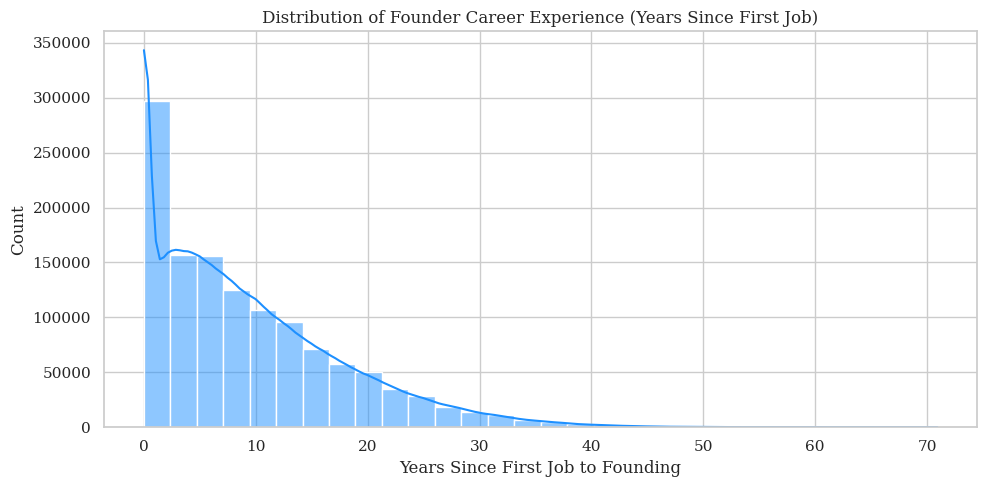

In [5]:
# Plot distribution of overall career experience
plt.figure(figsize=(10, 5))
sns.histplot(df['years_since_first_job'].dropna(), bins=30, kde=True, color='dodgerblue')
plt.title("Distribution of Founder Career Experience (Years Since First Job)")
plt.xlabel("Years Since First Job to Founding")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

--- Prior Position Seniority Frequencies ---
prior_seniority
5.0    235648
1.0    217336
2.0    204495
NaN    149515
4.0    125970
6.0    125298
3.0    108342
7.0     72581
Name: count, dtype: int64


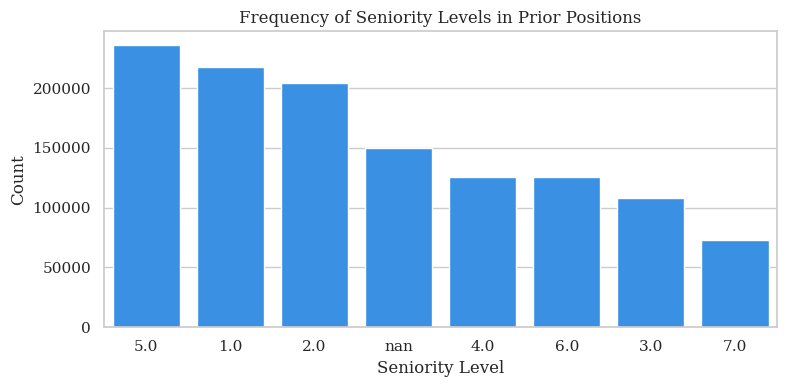

In [6]:
print("--- Prior Position Seniority Frequencies ---")
sen_counts = df['prior_seniority'].value_counts(dropna=False)
print(sen_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=sen_counts.index.astype(str), y=sen_counts.values, color="dodgerblue")
plt.title("Frequency of Seniority Levels in Prior Positions")
plt.ylabel("Count")
plt.xlabel("Seniority Level")
plt.tight_layout()
plt.show()

--- Prior Position Job Category Frequencies ---
prior_job_category_v2
Sales         265322
Marketing     233583
Engineer      184267
Admin         158564
Finance        87185
Operations     85484
Scientist      75265
Name: count, dtype: int64


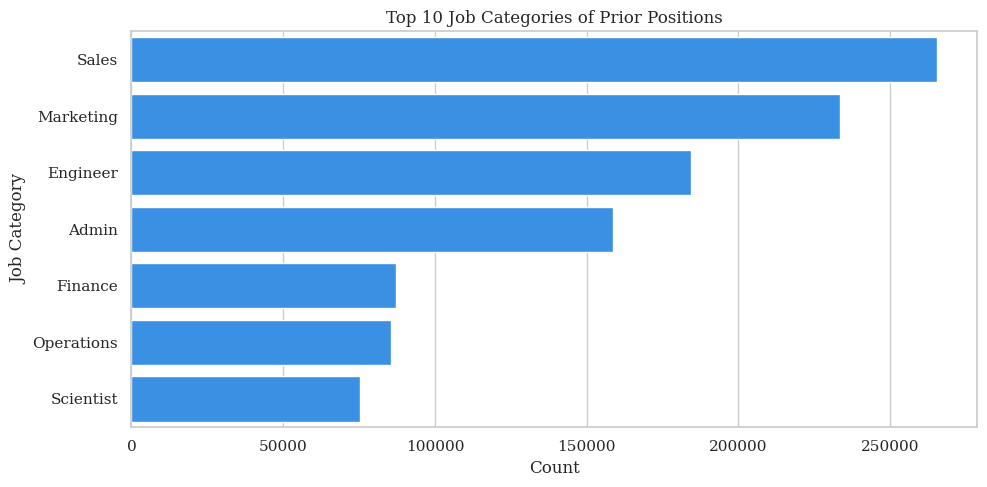

In [7]:
print("--- Prior Position Job Category Frequencies ---")
cat_counts = df['prior_job_category_v2'].value_counts().head(10)
print(cat_counts)

plt.figure(figsize=(10, 5))
sns.barplot(y=cat_counts.index.astype(str), x=cat_counts.values, color="dodgerblue")
plt.title("Top 10 Job Categories of Prior Positions")
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()

In [8]:
print("--- Prior Position Title Frequencies ---")
title_counts = df['prior_title_raw'].value_counts().head(10)
print(title_counts)

--- Prior Position Title Frequencies ---


prior_title_raw
Founder              24634
Co-Founder           16051
President            10687
Owner                10033
Software Engineer     6926
CEO                   6737
Intern                6285
Consultant            5588
Founder & CEO         5028
Partner               5020
Name: count, dtype: int64


--- Prior Position Salary Statistics (in USD) ---
count    1.089626e+06
mean     1.039639e+05
std      7.944941e+04
min      5.802260e+02
25%      4.432876e+04
50%      7.650449e+04
75%      1.463769e+05
max      3.000000e+06
Name: prior_salary, dtype: float64


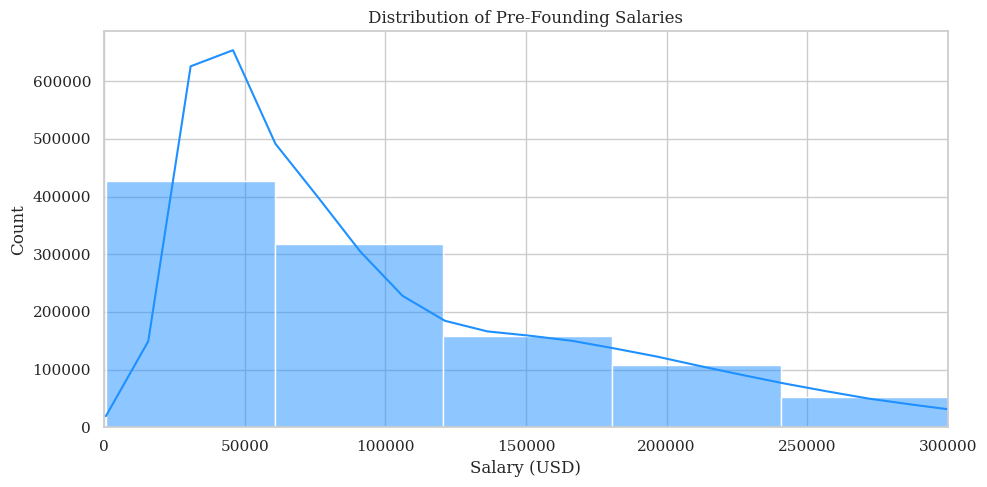

In [9]:
print("--- Prior Position Salary Statistics (in USD) ---")
print(df['prior_salary'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df[df['prior_salary'] > 0]['prior_salary'].dropna(), bins=50, kde=True, color='dodgerblue')
plt.title("Distribution of Pre-Founding Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.xlim(0, 300000)
plt.tight_layout()
plt.show()

In [10]:
print("--- Prior Position Industry (NAICS) Frequencies ---")
naics_counts = df['prior_naics_description'].value_counts().head(10)
print(naics_counts)

--- Prior Position Industry (NAICS) Frequencies ---
prior_naics_description
Colleges, Universities, and Professional Schools    72397
Software Publishers                                 63583
Portfolio Management and Investment Advice          14057
Custom Computer Programming Services                13566
Other Computer Related Services                     13194
Other Services Related to Advertising               12298
Miscellaneous Intermediation                        10993
Commercial Banking                                   9960
All Other Telecommunications                         9948
Advertising Agencies                                 9728
Name: count, dtype: int64


In [11]:
print("--- PitchBook Venture Outcomes ---")
df['received_funding'] = np.where(
    (df['SeriesA'] == 1) | 
    (df['TOTALRAISED'] > 0) | 
    (df['DEALSIZE'] > 0), 1, 0
)
df['has_exit'] = np.where(df['Acquired_IPO'] == 1, 1, 0)

print(f"Total ventures in dataset: {len(df):,}")
print(f"Ventures matched to PitchBook: {df['YEARFOUNDED'].notna().sum():,}")
print(f"Ventures that received VC funding: {df['received_funding'].sum():,} ({df['received_funding'].mean()*100:.2f}%)")
print(f"Ventures with successful exit (Acquisition/IPO): {df['has_exit'].sum():,} ({df['has_exit'].mean()*100:.2f}%)")
print(f"Ventures that went bankrupt: {df['Bankrupt'].sum():,} ({df['Bankrupt'].mean()*100:.2f}%)")

--- PitchBook Venture Outcomes ---
Total ventures in dataset: 1,239,185
Ventures matched to PitchBook: 58,907
Ventures that received VC funding: 47,466 (3.83%)
Ventures with successful exit (Acquisition/IPO): 24,705 (1.99%)
Ventures that went bankrupt: 13,125.0 (21.74%)


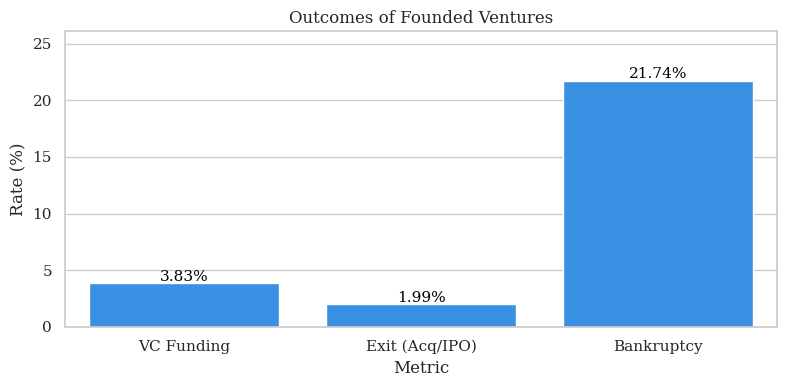

In [12]:
# Plot outcome rates
outcome_df = pd.DataFrame({
    'Metric': ['VC Funding', 'Exit (Acq/IPO)', 'Bankruptcy'],
    'Rate (%)': [df['received_funding'].mean()*100, df['has_exit'].mean()*100, df['Bankrupt'].mean()*100]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=outcome_df, x='Metric', y='Rate (%)', color='dodgerblue')
plt.title("Outcomes of Founded Ventures")
plt.ylabel("Rate (%)")
plt.ylim(0, max(outcome_df['Rate (%)']) * 1.2)
for index, row in outcome_df.iterrows():
    plt.text(index, row['Rate (%)'] + 0.2, f"{row['Rate (%)']:.2f}%", color='black', ha="center")
plt.tight_layout()
plt.show()